# Project 3 - Sales Analysis - Machine Learning

## Objectives

- Transform the Date column to pandas datetime
- Read data from combined csv file created from ETL processes
- Create machine learning model to predict new hypothesis data
- Show plots to attempt to answer new hypothesis


## Inputs

CSV files used:

Sales_InvoiceData_Visualization.csv


## Outputs

Pipeline for use in streamlit 
Plots to show the data and attempt to answer the hypothesis


## Additional Comments

- Developed an experimental ETL library which is in this project (modETL_library.py)   
  Has lots of cool features so will be interesting to see how it works "in the field"

Used various AI tools to help with the visualisation process:
- ChatGPT
- GitHub Copilot

See Documents/What_AI_Used_For.md for more details.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [19]:
%matplotlib inline

#iimport libraries
import os
import pandas as pd
import seaborn as sns
import plotly.express as px
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#for ML experiments
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

#for creating the pipeline file needed by streamlit/Heroku
import joblib

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT


# Hypothesis Being Tested

- What are the predicted sales for store types by month for next year?
- What are the predicted sales for stores in areas of high unemployment by month for next year?

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [20]:
#model and image paths

#for test against existing values
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_test_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis10_test_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis10_test_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis10_test_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS10_TEST_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis10_test_forecast.png"

#for new predictions
CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis9_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis9_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis9_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS9_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis9_predictions_forecast.png"

CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/linear_regression_hypothesis10_predictions_pipeline.pkl"
CNST_STR_LINEAR_PLOT_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/linear_regression_hypothesis10_predictions_forecast.png"
CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLPIPELINESPATH + "/randomforest_hypothesis10_predictions_pipeline.pkl"
CNST_STR_FOREST_PLOT_HYPOTHESIS10_PREDICTIONS_PATH = modGlobal.CNST_STR_MLREPORTIMAGESPATH + "/forest_regression_hypothesis10_predictions_forecast.png"


#DataFrame vars for visualisation
dfSalesDataML = None
dfSalesDataML_Work = None
dfTempML = None

#ML vars
dfTrain = pd.DataFrame()
dfTest = pd.DataFrame()
dfXTrain = pd.DataFrame()
dfyTrain = pd.DataFrame()
dfXTest = pd.DataFrame()
dfyTest = pd.DataFrame()
dfPlot = pd.DataFrame()
dfPredictedSales = pd.DataFrame()
dfSalesDataML_Temp1 = None
dfSalesDataML_Temp2 = None
dfSalesDataML_GroupedByTerritory = None
dfSalesDataML_GroupedByCustomer = None
dfSalesDataML_2017Predicted = None
dfSalesDataML_2018Predicted = None
df2018Monthly = None
df2018MonthlyPredicted = None
df2018Territory = None

lstNumericFeatures = list()
lstCategoricalFeatures = list()
lstFeatures = list()
lstStores = list()
lstSales = list()
lstMarkdown = list()

strTarget = ""

objModel = None
objPipeline = None
objMissingPreviousSales = None
objNumericTransformer = None
objCategoricalTransformer = None
objPreProcessor = None
objyPred = None
objyPred = None
objMissingColumns = None

fltMAE = 0.0
fltRMSE = 0.0
fltR2 = 0.0
fltActualTotal = 0.0
fltPredictedTotal = 0.0
fltDifference = 0.0
fltDifferencePercent = 0.0
flt2018Total = 0.0

intTestYear = 0
intPreviousYear = 0

#other vars
intYear = 0
fig = None
ax = None
intNum = 0
dictDataFrames = dict()
objPipeline = None
objModel = None
X = None
X_Const = None
y = None


## Set Current Directory To Base Project Directory

In [21]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing and Copy Into dfSales_DataSet_Work

In [22]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
#open into DataFrame which can be re-used during visualisations for filtering etc
dfSalesDataML = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]

#load special csv file for machine learning
dfSalesDataML_GroupedByTerritory = dictDataFrames["Sales_InvoiceData_GroupedByTerritory_Visualisation.csv"]

#load second special csv file for machine learning 
dfSalesDataML_GroupedByCustomer = dictDataFrames["Sales_InvoiceData_GroupedByCustomer_Visualisation.csv"]

3 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_GroupedByTerritory_Visualisation.csv
Sales_InvoiceData_GroupedByCustomer_Visualisation.csv
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


## Transform Date Column To Datetime Format

In [23]:
#transform Date to datetime
dfSalesDataML["InvoiceDate"] = pd.to_datetime(dfSalesDataML["InvoiceDate"], format="%d/%m/%Y")

#check schema
dfSalesDataML.dtypes

#create a working copy of the base DataFrame
dfSalesDataML_Work = dfSalesDataML.copy()


# Initailise Work DataFrame

In [24]:
#setup work DataFrame
dfSalesDataML_Work = dfSalesDataML.copy() 


## Check Special csv For Any Data Anomalies That Might Skew Regression

Seems a bit stange foing this here, but actually a little EDA beforehand i.e. double checking is never a bad idea

In [25]:
#show DataFrame
dfSalesDataML_GroupedByTerritory.head(1000)


,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
0,0,Central/E.Anglia,20113,2011,55064.96
1,20,EU INV,20113,2011,6879.71
2,71,Non EU,20113,2011,220568.38
3,61,London,20113,2011,7376.94
4,50,House Account,20113,2011,1113.27
...,...,...,...,...,...
995,1261,Midlands and West,20167,2016,26122.96
996,1173,Central/E.Anglia,20167,2016,5346.21
997,1249,Midlands and East,20167,2016,19042.24
998,1185,EU,20167,2016,21742.57


## Observations: Aggregate The Data By TerritoryCodes With Monthly Invoice Totals

Some data anomalies appear:

Territory: 
- record 135 - territory of "none" (??) this is actually a real value, why is it in the data?
- Record 88 & 89 - West Midlands (record 592), also West Midlands (East) and West Midlands (West) 
  Why does West Midlands exist on its own?
  Also why no East Midlands East/West?(!)


# Hypothesis 9

What are the predicted sales per month for next year?


# Linear Regression Model - Hypothesis 9 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [26]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and traing data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train


print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)



print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred


#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Linear Regression Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_TEST_PATH)


Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Linear Regression...
Training complete.

Linear Regression Results
MAE:  £18,609.06
RMSE: £29,873.94
R²:   0.6504
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,822,519.16
Difference:     £-6,822,519.16
Difference %:   -inf%

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt     Difference  DifferencePercent
     20171   650412.12         617868.137787   32543.982213           5.003594
     20172   599293.48         612276.445989  -12982.965989          -2.166379
     20173   666348.29         647531.676740   18816.613260           2.823841
     20174   437180.74         573343.513160 -136162.773160         

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/276217588.py:233: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: # Linear Regression Model - Hypothesis 9 - Test

Wow! The R-squared is 0.6993, which is close enough to 1 to say this model works!

The OLS Regression has an R-squared of 0.822 while InvoiceAmt is also near 1, this proves that Hypothesis Zero is
not met with this regression model, next will put in a plot


# Linear Regression Plot - Hypothesis 9 - Test Plot

Visualise the model results

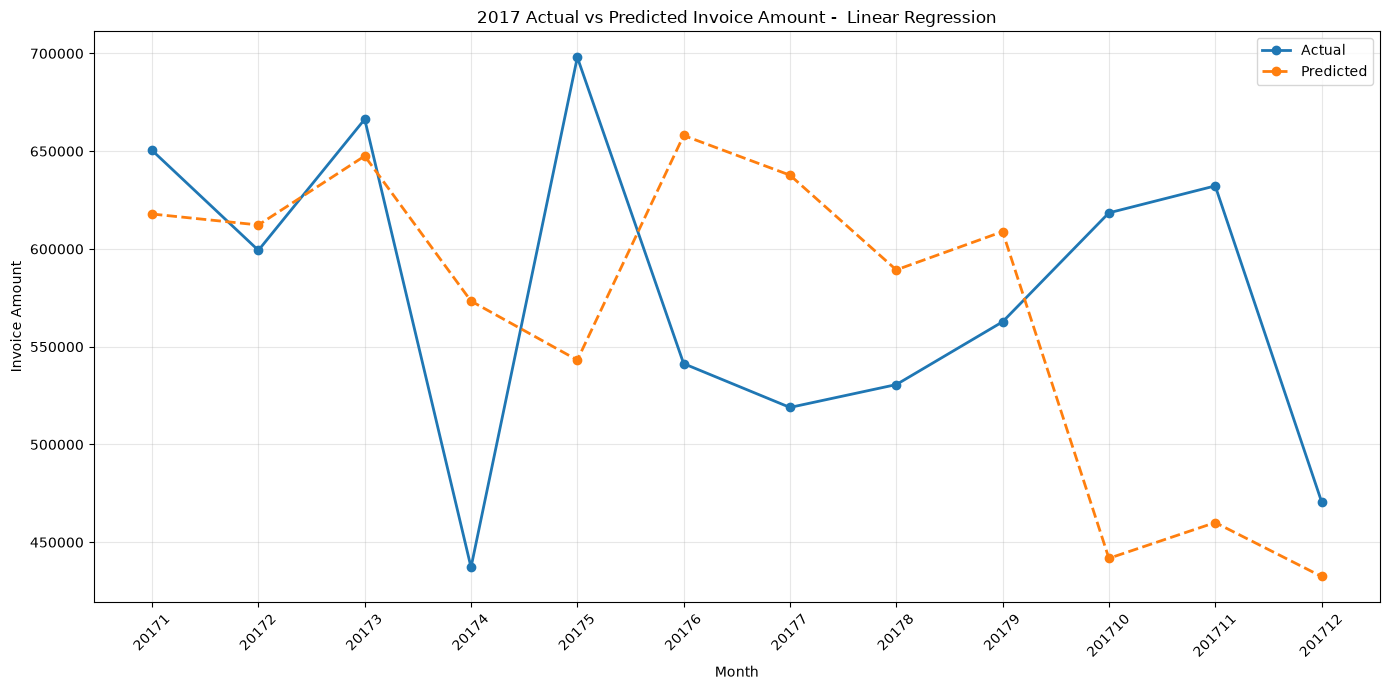

In [27]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount -  Linear Regression")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Observations: Linear Regression Model - Hypothesis 9 - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the dfSalesDataML_GroupedByTerritory DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [28]:
#2017 prediction model DataFrame
dfTest

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month
1052,1418,Central/E.Anglia,20171,2017,13166.22,71
1062,1430,EU,20171,2017,46796.81,71
1063,1444,EU INV,20171,2017,4018.60,71
1072,1457,East Midlands,20171,2017,22622.31,71
1060,1469,House Account,20171,2017,66390.59,71
...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12
1667,1633,South West,201712,2017,8935.62,12
1649,1641,UK Projects,201712,2017,6374.36,12
1650,1653,West Midlands,201712,2017,23972.99,12


In [29]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Next Forest Regression!

# Random Forest - Hypothesis 9 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [30]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and training data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()


# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

print("dfTrain columns:")
print(dfTrain.columns.tolist())

print()

print("dfTest columns:")
print(dfTest.columns.tolist())

print()

print("Features required:")
print(lstFeatures)

dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)



#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)
print()


print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred

#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Random Forest Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby("YearMonth")[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Random Forest Results")
print("=" * len("Random Forest Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH)



Invoice Amounts Per Territory: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
dfTrain columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

dfTest columns:
['Unnamed: 0', 'TerritoryCodes', 'YearMonth', 'Year', 'InvoiceAmt', 'Month']

Features required:
['TerritoryCodes', 'Year', 'Month']
Training Random Forest...

Training complete.

Random Forest Results
MAE:  £13,980.93
RMSE: £23,621.78
R²:   0.7814
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,513,705.73
Difference:     £-6,513,705.73
Difference %:   -inf%

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt    Difference  DifferencePercent
     20171   650412.12         539245.952905 111166.167095          1

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/3784091431.py:255: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: Random Forest Model - Hypothesis 9 - Test

Wow! The R-squared is 0.9692 which is *so* close to 1 I think it invalidates this model, as close is good
but almost 1 is suspicious, could it really be that close??

The OLS Regression has an R-squared of 0.004 which tells us this model doesn't work!
Still for science it shall be put into a plot for analysis

## Forest Regression Model - Hypothesis 9 - Test Plot

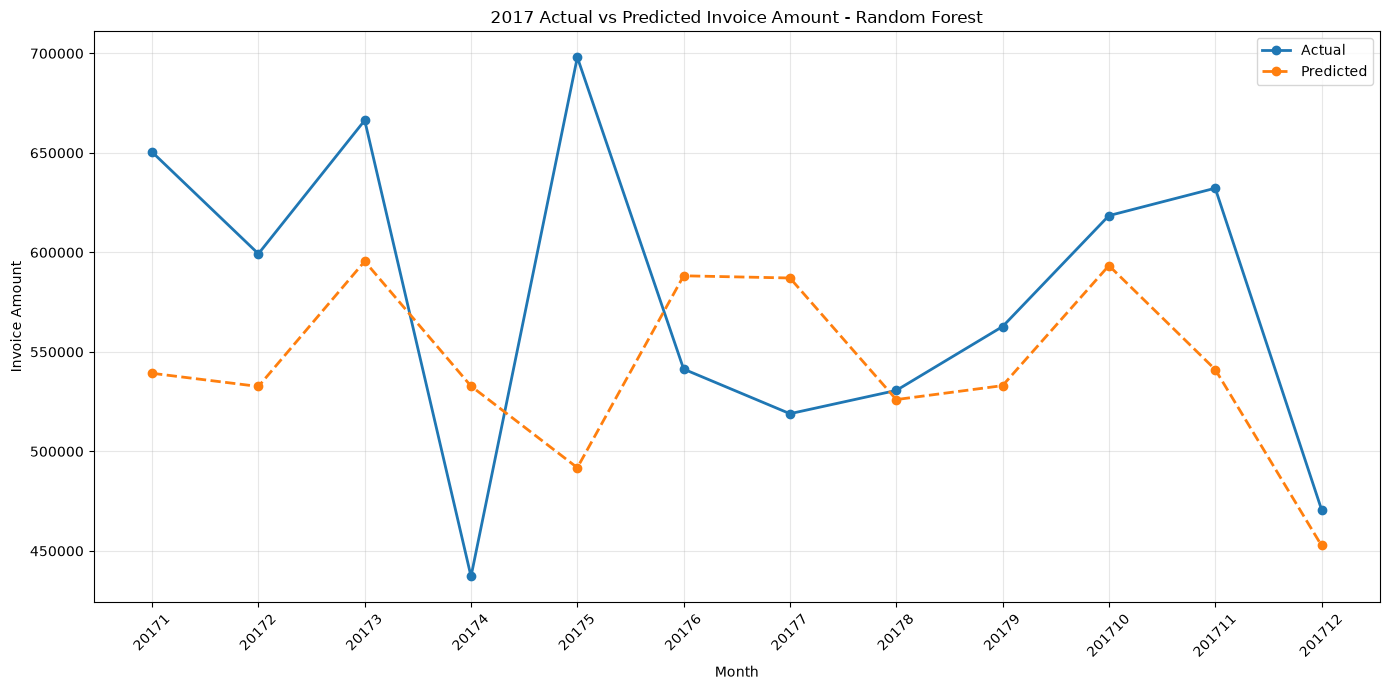

In [31]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Observations: # Random Forest Model - Hypothesis 9 - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [32]:
#2017 prediction model DataFrame
dfTest = dfTest[dfTest["Year"] == 2017]
dfTest

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt,Month
1052,1418,Central/E.Anglia,20171,2017,13166.22,71
1062,1430,EU,20171,2017,46796.81,71
1063,1444,EU INV,20171,2017,4018.60,71
1072,1457,East Midlands,20171,2017,22622.31,71
1060,1469,House Account,20171,2017,66390.59,71
...,...,...,...,...,...,...
1651,1621,South East/London,201712,2017,12316.12,12
1667,1633,South West,201712,2017,8935.62,12
1649,1641,UK Projects,201712,2017,6374.36,12
1650,1653,West Midlands,201712,2017,23972.99,12


In [33]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

,Unnamed: 0,TerritoryCodes,YearMonth,Year,InvoiceAmt
1052,1418,Central/E.Anglia,20171,2017,13166.22
1053,1610,South East/London,20171,2017,19915.32
1054,1563,Scotland,20171,2017,3086.12
1055,1642,West Midlands,20171,2017,39176.13
1056,1665,West Midlands (West),20171,2017,346.90
...,...,...,...,...,...
1664,1453,EU INV,201712,2017,2747.45
1665,1441,EU,201712,2017,27619.14
1666,1609,South East,201712,2017,8465.35
1667,1633,South West,201712,2017,8935.62


## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works really well

Interesting the Linear Regression plot has a bump around the 250,000 sales mark where are the Forest Regression
model does not, but it does skew more tot he left than the actual data, so the Linear Regression model is a better 
fit for this data

Next challenge see if I can find a plot whereby I can show both predicted and actual 2016 sales in the same plot!


## Predict 2018 Figures

Same routine but now predicting unknown values

In [34]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

objModel = LinearRegression()


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01          11943.687784
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01          12702.080333
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17          13482.999338
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01          14077.198181
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01          14325.461763
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00          14161.268056
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01          13628.612633
    Centra

## Observations: Predict 2018 Figures - Linear Regression Model



## Predict 2018 Figures - Linear Regression Plot

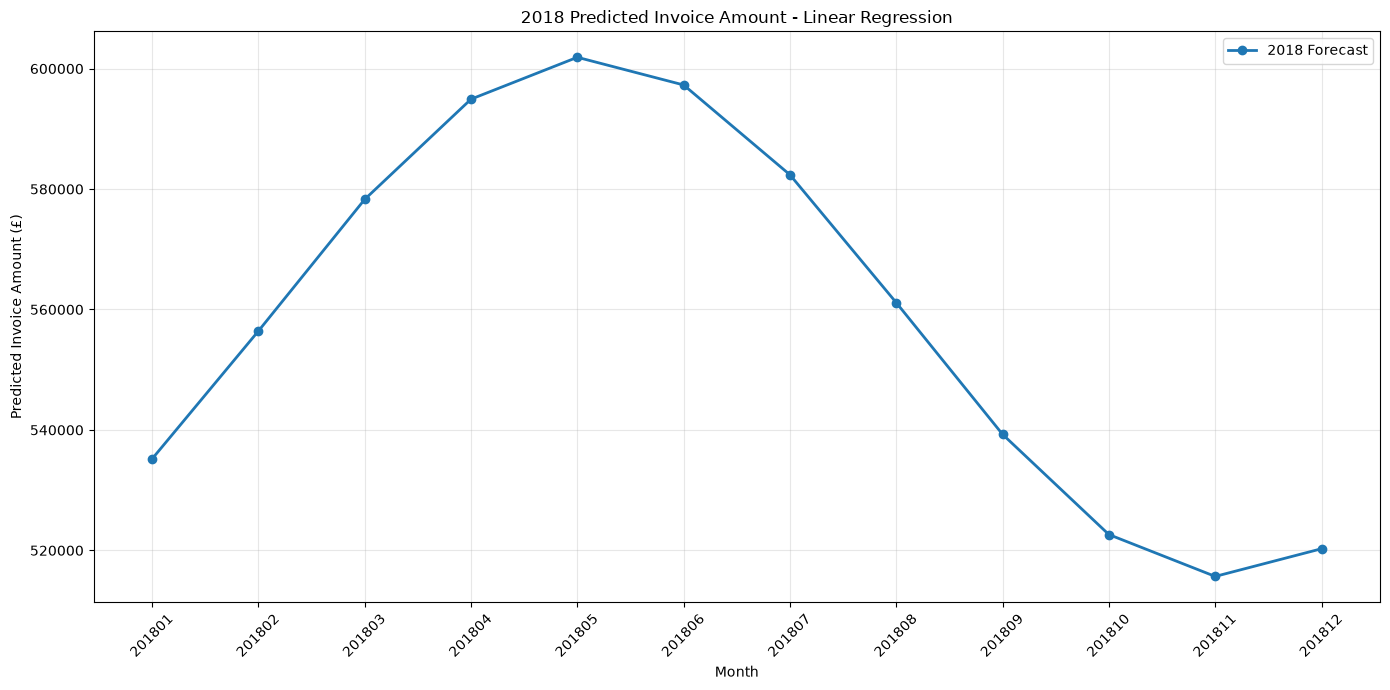

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt
     20171   650412.12         539245.952905
     20172   599293.48         532635.255150
     20173   666348.29         595513.680663
     20174   437180.74         532794.020785
     20175   698024.62         491817.080096
     20176   541352.49         588233.302547
     20177   518946.20         587128.455534
     20178   530633.43         526039.356527
     20179   562733.90         533056.745938
    201710   618465.98         593365.389245
    201711   632253.48         541149.947675
    201712   470797.80         452726.544300


In [35]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)


plt.title("2018 Predicted Invoice Amount - Linear Regression")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(dfPlot[
    [
        "YearMonth",
        "InvoiceAmt",
        "Predicted_InvoiceAmt"
    ]
].to_string(index=False))



## Predict 2018 Figures - Random Forest

In [36]:
# ============================================================
# PREPARE COMPLETE DATASET
# ============================================================

dfSalesDataML_Work = (
    dfSalesDataML_GroupedByTerritory.copy()
)


# ============================================================
# CREATE MONTH
# ============================================================

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
).astype(int)


#cyclic features
dfSalesDataML_Work["MonthSin"] = np.sin(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

dfSalesDataML_Work["MonthCos"] = np.cos(
    2 * np.pi * dfSalesDataML_Work["Month"] / 12
)

# ============================================================
# TRAINING DATA
#
# Use ALL available historical data:
# 2011-2017
# ============================================================

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2017
].copy()


print("Training Rows:", len(dfTrain))

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print()


# ============================================================
# FEATURES
# ============================================================

lstFeatures = [
    "TerritoryCodes",
    "Year",
    "MonthSin",
    "MonthCos"
]

strTarget = "InvoiceAmt"


dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]


# ============================================================
# PREPROCESSING
# ============================================================

lstNumericFeatures = [
    "Year",
    "MonthSin",
    "MonthCos"
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)


objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


# ============================================================
# MODEL
# ============================================================

#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)


objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)


# ============================================================
# TRAIN MODEL
# ============================================================

print("Training Linear Regression using 2011-2017...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training complete.")
print()


# ============================================================
# CREATE 2018 PREDICTION DATA
# ============================================================

# Get all territories that existed in 2017

lstTerritories = sorted(
    dfSalesDataML_Work[
        dfSalesDataML_Work["Year"] == 2017
    ]["TerritoryCodes"]
    .dropna()
    .unique()
)


# Create 12 months for every territory

df2018Predict = pd.DataFrame(
    [
        {
            "TerritoryCodes": territory,
            "Year": 2018,
            "Month": month,
            "YearMonth": 201800 + month
        }
        for territory in lstTerritories
        for month in range(1, 13)
    ]
)

#add cyclic features
df2018Predict["MonthSin"] = np.sin(
    2 * np.pi * df2018Predict["Month"] / 12
)

df2018Predict["MonthCos"] = np.cos(
    2 * np.pi * df2018Predict["Month"] / 12
)




# ============================================================
# PREDICT 2018
# ============================================================

dfX2018 = df2018Predict[
    lstFeatures
]


obj2018Predictions = (
    objPipeline.predict(
        dfX2018
    )
)


# Add predictions

df2018Predict[
    "Predicted_InvoiceAmt"
] = obj2018Predictions


# ============================================================
# DISPLAY PREDICTIONS
# ============================================================

print("2018 Forecast")
print("=" * 30)

print(
    df2018Predict.to_string(
        index=False
    )
)

print()


# ============================================================
# TOTAL 2018 FORECAST
# ============================================================

flt2018Total = (
    df2018Predict[
        "Predicted_InvoiceAmt"
    ].sum()
)

df2018Monthly = (
    df2018Predict
    .groupby("YearMonth")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Monthly)

df2018Territory = (
    df2018Predict
    .groupby("TerritoryCodes")[
        "Predicted_InvoiceAmt"
    ]
    .sum()
    .reset_index()
)

print(df2018Territory)



print(
    f"Predicted 2018 Sales: "
    f"£{flt2018Total:,.2f}"
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols(
    "InvoiceAmt ~ TerritoryCodes + Year + MonthSin + MonthCos",
    data=dfSalesDataML_Work
).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_PREDICTIONS_PATH)

Training Rows: 1669
Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Training Linear Regression using 2011-2017...
Training complete.

2018 Forecast
      TerritoryCodes  Year  Month  YearMonth      MonthSin      MonthCos  Predicted_InvoiceAmt
    Central/E.Anglia  2018      1     201801  5.000000e-01  8.660254e-01           8184.408228
    Central/E.Anglia  2018      2     201802  8.660254e-01  5.000000e-01           8848.773390
    Central/E.Anglia  2018      3     201803  1.000000e+00  6.123234e-17           8857.146081
    Central/E.Anglia  2018      4     201804  8.660254e-01 -5.000000e-01           8825.556294
    Central/E.Anglia  2018      5     201805  5.000000e-01 -8.660254e-01           8107.575402
    Central/E.Anglia  2018      6     201806  1.224647e-16 -1.000000e+00           8379.030402
    Central/E.Anglia  2018      7     201807 -5.000000e-01 -8.660254e-01           8122.773322
    Centra

## Observations: Predict 2018 Figures - Random Forest Model



## Predict 2018 Figures- Random Forest Plot

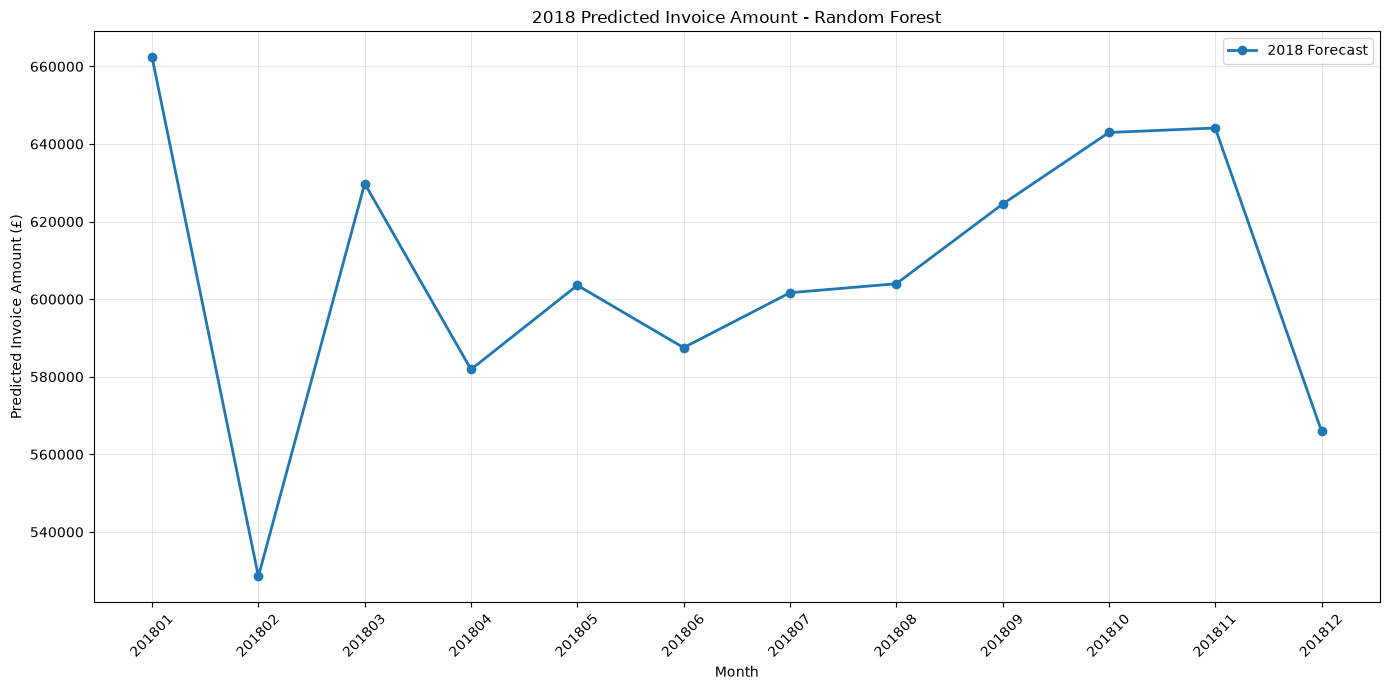

 YearMonth  InvoiceAmt  Predicted_InvoiceAmt
     20171   650412.12         539245.952905
     20172   599293.48         532635.255150
     20173   666348.29         595513.680663
     20174   437180.74         532794.020785
     20175   698024.62         491817.080096
     20176   541352.49         588233.302547
     20177   518946.20         587128.455534
     20178   530633.43         526039.356527
     20179   562733.90         533056.745938
    201710   618465.98         593365.389245
    201711   632253.48         541149.947675
    201712   470797.80         452726.544300


In [ ]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    df2018Monthly["YearMonth"].astype(str),
    df2018Monthly["Predicted_InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="2018 Forecast"
)



plt.title("2018 Predicted Invoice Amount - Random Forest")
plt.xlabel("Month")
plt.ylabel("Predicted Invoice Amount (£)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(dfPlot[
    [
        "YearMonth",
        "InvoiceAmt",
        "Predicted_InvoiceAmt"
    ]
].to_string(index=False))



# Hypothesis 10

What are the predicted sales per territory for next year?

# Linear Regression Model - Hypothesis 10 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [37]:
#group data by invoice total per month per territory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Territory Per Month: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2017
dfSalesDataML_Temp = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)

dfSalesDataML_Work["Month"] = (
    dfSalesDataML_Work["YearMonth"] % 100
)


#create test and traing data
#
#IMPORTANT:
#2017 is the test year
#2016 and below is NOT used as the test data

dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

#show what is being used
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()
#show test and training date ranges
print(f"Training Date Range: {intStart} To 2016")
print("Testing Date Range: 2017")
print()



# Training = 2011-2016
dfTrain = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] <= 2016
].copy()

# Testing = 2017
dfTest = dfSalesDataML_Work[
    dfSalesDataML_Work["Year"] == 2017
].copy()

# Sort
dfTrain.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

dfTest.sort_values(
    by=["YearMonth", "TerritoryCodes"],
    inplace=True
)

print("Training Rows:", len(dfTrain))
print("Testing Rows:", len(dfTest))

print()

print(
    "Training Years:",
    sorted(dfTrain["Year"].unique())
)

print(
    "Testing Years:",
    sorted(dfTest["Year"].unique())
)

print(
    dfSalesDataML_GroupedByTerritory["Year"].unique()
)



#define features to use
lstFeatures = [
    "TerritoryCodes",
    "Year",
    "Month",
]

#define target
strTarget = "InvoiceAmt"

dfXtrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


lstNumericFeatures = [
    "Year",
    "Month",
]

lstCategoricalFeatures = [
    "TerritoryCodes"
]


objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

objPreProcessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#model
objModel = LinearRegression()

objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train


print("Training Linear Regression...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)



print("Training complete.")
print()

#predict 2017
objyPred = objPipeline.predict(
    dfXTest
)

dfSalesDataML_2017Predicted = dfTest.copy()

dfSalesDataML_2017Predicted[
    "Predicted_InvoiceAmt"
] = objyPred


#metrics
fltMAE = mean_absolute_error(
    dfyTest,
    objyPred
)

fltRMSE = np.sqrt(
    mean_squared_error(
        dfyTest,
        objyPred
    )
)

fltR2 = r2_score(
    dfyTest,
    objyPred
)


print("Linear Regression Results")
print("=" * 30)

print(f"MAE:  £{fltMAE:,.2f}")
print(f"RMSE: £{fltRMSE:,.2f}")
print(f"R²:   {fltR2:.4f}")


#totals
ltActualTotal = (
    dfSalesDataML_2017Predicted[
        "InvoiceAmt"
    ].sum()
)

fltPredictedTotal = (
    dfSalesDataML_2017Predicted[
        "Predicted_InvoiceAmt"
    ].sum()
)

fltDifference = (
    fltActualTotal -
    fltPredictedTotal
)

fltDifferencePercent = (
    fltDifference /
    fltActualTotal
) * 100


#inspect 2017 forecast
print("Inspect 2017 Forecast")
print("=" * len("Inspect 2017 Forecast"))
print()
print(f"Actual 2017:    £{fltActualTotal:,.2f}")
print(f"Predicted 2017: £{fltPredictedTotal:,.2f}")
print(f"Difference:     £{fltDifference:,.2f}")
print(f"Difference %:   {fltDifferencePercent:.2f}%")
print()


dfPlot = (
    dfSalesDataML_2017Predicted
    .groupby(["YearMonth","TerritoryCodes"])[
        ["InvoiceAmt", "Predicted_InvoiceAmt"]
    ]
    .sum()
    .reset_index()
)

dfPlot["Difference"] = (
    dfPlot["InvoiceAmt"]
    - dfPlot["Predicted_InvoiceAmt"]
)

dfPlot["DifferencePercent"] = (
    dfPlot["Difference"]
    / dfPlot["InvoiceAmt"]
) * 100

print(
    dfPlot.to_string(index=False)
)


#evaluate performance of the model
fltMAE = mean_absolute_error(dfyTest, objyPred)

fltRMSE = np.sqrt(
    mean_squared_error(dfyTest, objyPred)
)

fltR2 = r2_score(dfyTest, objyPred)

#show results
print("Linear Regression Results")
print("=" * len("Linear Regression Results"))
print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()


#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ TerritoryCodes + Year + Month", # Month, + Day + MonthSin + MonthCos", # + Quarter ", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save pipelie to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH
)

#tell user saved
print("Pipeline Saved To:")
print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS10_TEST_PATH)



Invoice Amounts Per Territory Per Month: 2011 To 2016
Training Rows: 1418
Testing Rows: 251

Training Date Range: 2011 To 2016
Testing Date Range: 2017

Training Rows: 1418
Testing Rows: 251

Training Years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Testing Years: [np.int64(2017)]
[2011 2012 2013 2014 2015 2016 2017]
Training Linear Regression...
Training complete.

Linear Regression Results
MAE:  £18,609.07
RMSE: £29,873.92
R²:   0.6504
Inspect 2017 Forecast

Actual 2017:    £0.00
Predicted 2017: £6,822,448.16
Difference:     £-6,822,448.16
Difference %:   -inf%

 YearMonth       TerritoryCodes  InvoiceAmt  Predicted_InvoiceAmt     Difference  DifferencePercent
     20171     Central/E.Anglia    13166.22          17083.353163   -3917.133163      -2.975139e+01
     20171                   EU    46796.81          23333.824592   23462.985408       5.013800e+01
     20171               EU INV     4018.60           -890.456005    4909.

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_14163/898121444.py:233: RuntimeWarning: divide by zero encountered in scalar divide
  fltDifference /


# Observations: # Linear Regression Model - Hypothesis 10 - Test

Wow! The R-squared is 0.4587 which is is close to midway but not conclusive the model works

The OLS Regression has an R-squared of 0.412 while InvoiceAmt is also nearer to 0, this does not prove that 
Hypothesis Zero is not met with this regression model, next it will put in a plot

# Linear Regression Plot - Hypothesis 10 - Test PLot

Visualise the model results

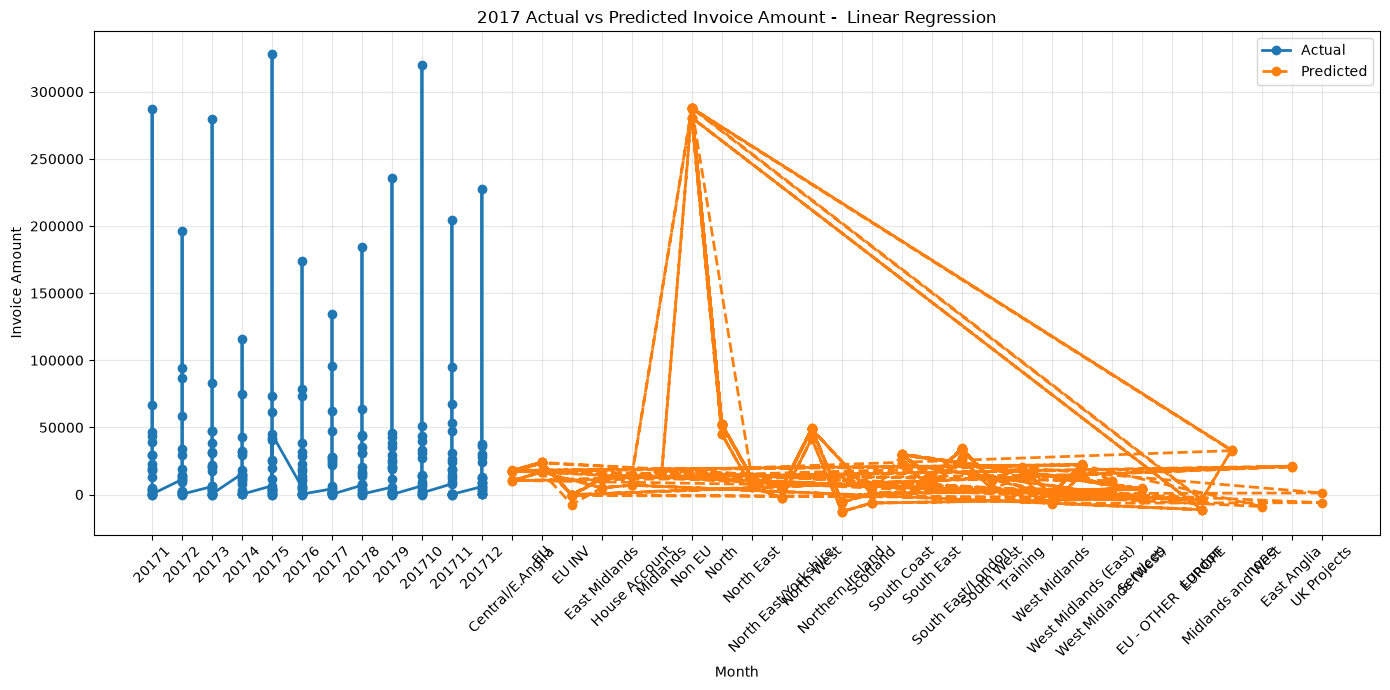

In [38]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["TerritoryCodes"],       #YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount -  Linear Regression")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Observations: Linear Regression Model - Hypothesis 10 - Test Plot

The prediction model is close to the original but slightly skewed to right more than the actual data
Will have a look at Random Forest and see if that is closer

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [ ]:
#2017 prediction model DataFrame
dfTest = dfTest[dfTest["Year"] == 2017]
dfTest

In [ ]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

# Random Forest - Hypothesis 10 - Test

First run a test comparing predicitons for last years values with the actual values to see how accurate the model is

In [36]:
#group data by invoice total per month per terrtiory BEFORE doing any ML to ensure accurate data going
#into the model

#use special csv file grouped by territory and yearmonth
dfSalesDataML_Work = dfSalesDataML_GroupedByCustomer.copy() 

#set year range
intYear= dfSalesDataML_Work["Year"].max() -1
intStart = dfSalesDataML_Work["Year"].min()

print(f"Invoice Amounts Per Customer: {intStart} To {intYear}")

#get above DataFrame and filter for JUST 2016
dfSalesDataML_Temp = dfSalesDataML_GroupedByCustomer[dfSalesDataML_GroupedByCustomer["Year"] == 2016].copy()

#sort by yearmonth
dfSalesDataML_Temp.sort_values(by=["YearMonth"], inplace=True)


dfTrain = dfSalesDataML_GroupedByCustomer.copy()
dfTest = dfSalesDataML_Temp.copy()

#show row data
print(f"Training Rows: {len(dfTrain)}")
print(f"Testing Rows: {len(dfTest)}")
print()

#show date range
print(f"Training Date Range: {intStart} To 2016")
print(f"Testing Date Range: 2016")
print()

#configure features and target
lstFeatures = [
    "CustomerID",
    "YearMonth",
    "Year",
]

#set target
strTarget = "InvoiceAmt"

#setup X and y for training and testing
dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]

dfXTest = dfTest[lstFeatures]
dfyTest = dfTest[strTarget]


#set numeric features
lstNumericFeatures = [
    "YearMonth",
    "Year",
]

#set categorical features
lstCategoricalFeatures = [
    "CustomerID"
]

#set numeric transformer
objNumericTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

#set categorical transformer
objCategoricalTransformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

#set column transformer
objPreProcessor= ColumnTransformer(
    transformers=[
        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),
        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#create random forest model
objModel = RandomForestRegressor(
    n_estimators=20,     #50
    max_depth=20,      #None
    min_samples_split=2, #2
    min_samples_leaf=1,  #1
    random_state=42,     
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        ("preprocessor", objPreProcessor),
        ("model", objModel)
    ]
)

#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXTrain,
    dfyTrain
)
print()

#get prediction==================================================
objyPred = objPipeline.predict(dfXTest)


#evaluate results
fltMAE = mean_absolute_error(dfyTest, objyPred)
fltRMSE = np.sqrt(mean_squared_error(dfyTest, objyPred))
fltR2 = r2_score(dfyTest, objyPred)

#print results
print("Random Forest Results")
print("=" * 30)

print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
print(f"R-Squared (R²):   {fltR2:.4f}")
print()

#show OLS model summary for InvoiceAmt
ols_model = smf.ols("InvoiceAmt ~ YearMonth + Year", # + DayOfWeek + WeekOfYear + Quarter + MonthSin + MonthCos", 
                    data=dfSalesDataML_Work).fit()
print(ols_model.summary())
print()

#save piepline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS10_TEST_PATH)



Invoice Amounts Per Customer: 2011 To 2016
Training Rows: 26759
Testing Rows: 3563

Training Date Range: 2011 To 2016
Testing Date Range: 2016

Training Random Forest...

Random Forest Results
Mean Absolute Error (MAE):  1,644.37
Root Mean Squared Error (RMSE): 3,494.88
R-Squared (R²):   0.7459

                            OLS Regression Results                            
Dep. Variable:             InvoiceAmt   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.933
Date:                Fri, 04 Sep 2026   Prob (F-statistic):              0.145
Time:                        13:23:13   Log-Likelihood:            -2.7862e+05
No. Observations:               26759   AIC:                         5.572e+05
Df Residuals:                   26756   BIC:                         5.573e+05
Df Model:                           2                                  

# Observations: # Random Forest Model - Hypothesis 10 - Test

Wow! The R-squared is 0.7459 which is a really good figure, hypothesis Zero is not met!

The OLS Regression has an R-squared of 0.000 which tells us this model doesn't work, but this is based on **just**
InvoiceAmt and so shall wait till the plot before making a final decision


## Linear Regression Model - Hypothesis 10 - Test Plot


/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_2375/2157501633.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


<Figure size 800x400 with 0 Axes>

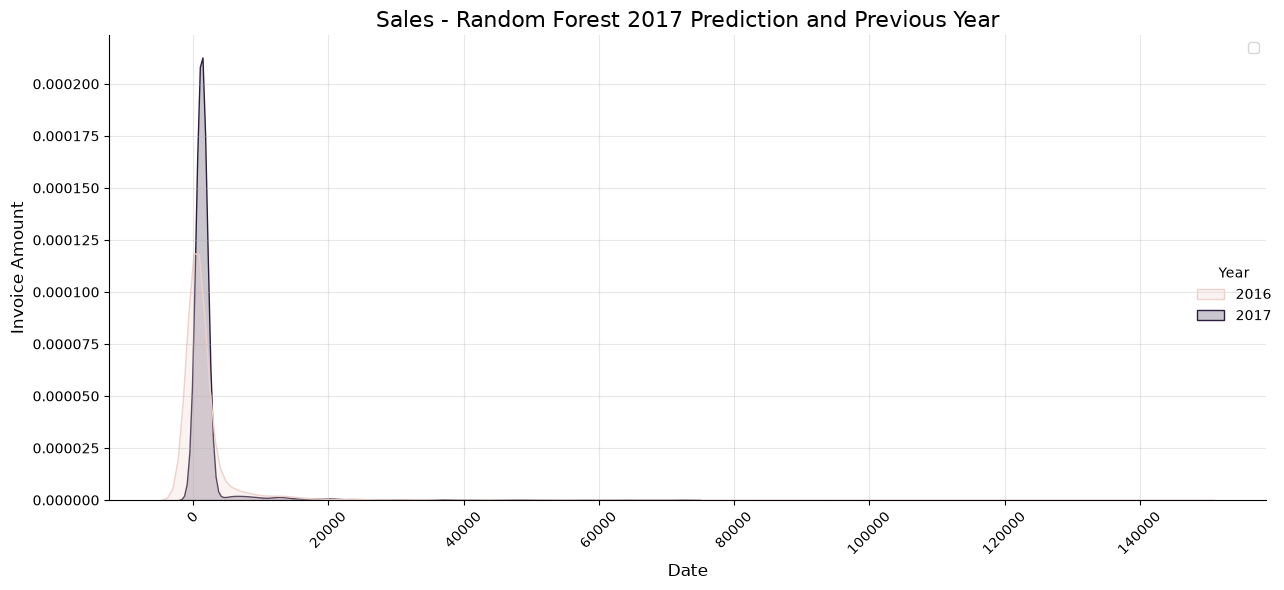

/var/folders/wv/yty584vs1kq76d7zd3rv5wpw0000gn/T/ipykernel_2375/2157501633.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


<Figure size 800x400 with 0 Axes>

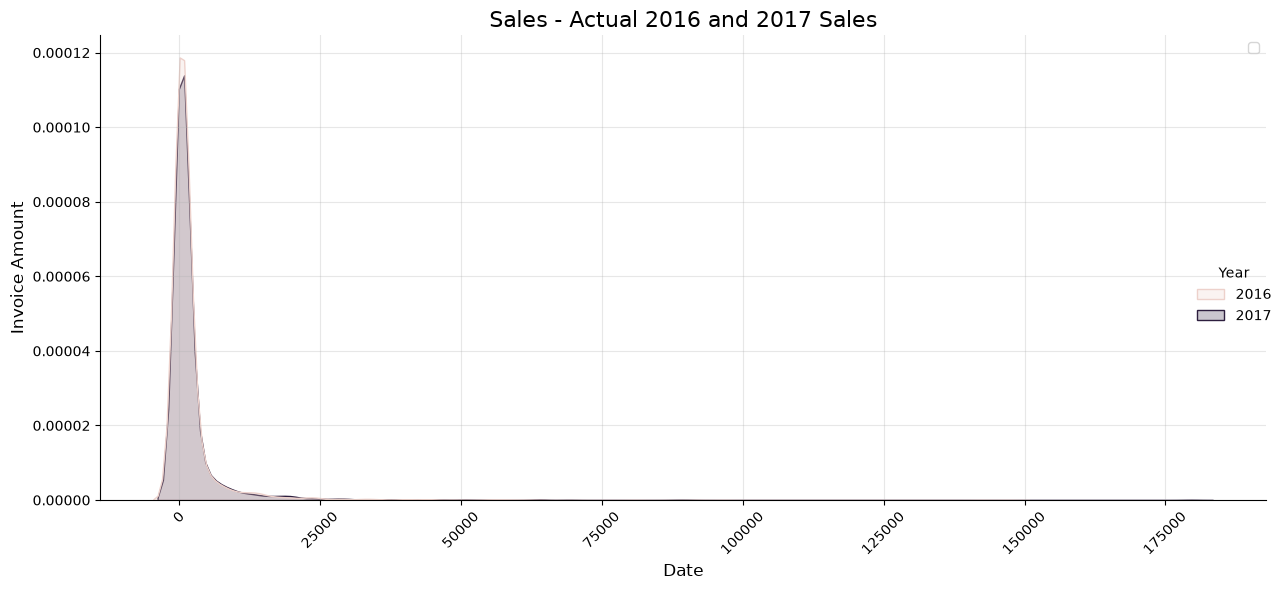

In [ ]:
#now plot the results for 2017 prediction with actual 2017 sales and previous year 2016 sales

plt.figure(figsize=(14, 7))

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["InvoiceAmt"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    dfPlot["YearMonth"].astype(str),
    dfPlot["Predicted_InvoiceAmt"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("2017 Actual vs Predicted Invoice Amount -  Linear Regression")
plt.xlabel("Month")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Observations: # Random Forest Model - Hypothesis 9 - Test Plot

The prediction model is quite close to the original will still include both plots in the dashboard so the customer
can see for themselves the difference

## Look At The DataFrames For Confirmation Of Model Accuracy

Look at the test DataFrame which holds the 2017 prediction and the actual 2017 data from  dfSalesDataML_GroupedByTerritory for 2017

In [ ]:
#2017 prediction model DataFrame
dfTest = dfTest[dfTest["Year"] == 2017]
dfTest

In [ ]:
#existing data for 2016/2017
dfSalesDataML_Work = dfSalesDataML_GroupedByTerritory[dfSalesDataML_GroupedByTerritory["Year"] == 2017] #.between(intPreviousYear, intYear)] 
dfSalesDataML_Work 

## Observations: DataFrame Comparison

Initially thought the model was corrupt and somehow had duplicated the data, but looking at the DataFrames it is
clear this is not the case, the model works but theLinear Regression plot looks a lot closer to the actual data


Next challenge see if I can find a plot whereby I can show both predicted and actual 2016 sales in the same plot!


In [ ]:
#random forest test compare last years sales with predicted values for same year
#saves pipeline into main pipelines folder and the same in the streamlit folder

# dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["InvoiceDate"])

# dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["InvoiceDate"].dt.isocalendar().week.astype(int)


#create and train model
#training:
#all years before 2016  
#
#Testing:
#2016 only
#
#2016 is deliberately NOT used for testing.

# dfTrain = dfSalesDataML_Work.copy()
# dfTrain = dfTrain[dfTrain["Year"] < 2016]
# dfTest = dfSalesDataML_Work.copy()
# dfTest = dfTest[dfTest["Year"] == 2016]

# #show row data
# print(f"Training Rows: {len(dfTrain)}")
# print(f"Testing Rows: {len(dfTest)}")
# print()

# #show date range
# print(f"Training Date Range: {dfTrain['InvoiceDate'].min()} To 2016")
# print(f"Testing Date Range: 2016")
# print()

# #configure features and target
# lstFeatures = [
#     "TerritoryCodes",
#     "Year",
#     "Month",
#     "Day",
#     # "DayOfWeek",
#     # "WeekOfYear",
#     # "Quarter",
#     # "MonthSin",
#     # "MonthCos"
# ]

# #set target
# strTarget = "InvoiceAmt"

# #setup X and y for training and testing
# dfXTrain = dfTrain[lstFeatures]
# dfyTrain = dfTrain[strTarget]

# dfXTest = dfTest[lstFeatures]
# dfyTest = dfTest[strTarget]


# #set numeric features
# lstNumericFeatures = [
#     "Year",
#     "Month",
#     "Day",
#     # "DayOfWeek",
#     # "WeekOfYear",
#     # "Quarter",
#     # "MonthSin",
#     # "MonthCos"
# ]

# #set categorical features
# lstCategoricalFeatures = [
#     "TerritoryCodes"
# ]

# #set numeric transformer
# objNumericTransformer = Pipeline(
#     steps=[
#         ("imputer", SimpleImputer(strategy="median"))
#     ]
# )

# #set categorical transformer
# objCategoricalTransformer = Pipeline(
#     steps=[
#         ("imputer", SimpleImputer(strategy="most_frequent")),
#         (
#             "onehot",
#             OneHotEncoder(
#                 handle_unknown="ignore"
#             )
#         )
#     ]
# )

# #set column transformer
# objPreProcessor= ColumnTransformer(
#     transformers=[
#         (
#             "numeric",
#             objNumericTransformer,
#             lstNumericFeatures
#         ),
#         (
#             "categorical",
#             objCategoricalTransformer,
#             lstCategoricalFeatures
#         )
#     ]
# )

# #create random forest model
# objModel = RandomForestRegressor(
#     n_estimators=20,     #50
#     max_depth=20,      #None
#     min_samples_split=2, #2
#     min_samples_leaf=1,  #1
#     random_state=42,     
#     n_jobs=-1
# )

# #create pipeline
# objPipeline = Pipeline(
#     steps=[
#         ("preprocessor", objPreProcessor),
#         ("model", objModel)
#     ]
# )

# #train model
# print("Training Random Forest...")

# objPipeline.fit(
#     dfXTrain,
#     dfyTrain
# )
# print()

# #get prediction==================================================
# objyPred = objPipeline.predict(dfXTest)


# #evaluate results
# fltMAE = mean_absolute_error(dfyTest, objyPred)
# fltRMSE = np.sqrt(mean_squared_error(dfyTest, objyPred))
# fltR2 = r2_score(dfyTest, objyPred)

# #print results
# print("Random Forest Results")
# print("=" * 30)

# print(f"Mean Absolute Error (MAE):  {fltMAE:,.2f}")
# print(f"Root Mean Squared Error (RMSE): {fltRMSE:,.2f}")
# print(f"R-Squared (R²):   {fltR2:.4f}")
# print()

# #show OLS model summary for InvoiceAmt
# ols_model = smf.ols("InvoiceAmt ~ InvoiceDate + Year + Month + Day", # + DayOfWeek + WeekOfYear + Quarter + MonthSin + MonthCos", 
#                     data=dfSalesDataML_Work).fit()
# print(ols_model.summary())
# print()

# #save piepline to main folder
# joblib.dump(
#     objPipeline,
#     CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH
# )

# print("Pipeline Saved To:")
# print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH)


# Observations - Random Forest Model - Hypothesis 12 - Test

The R Squared value is 0.7928 which is far enough from 0 to suggest the model is a good fit for the data  

The Mean Absolute Error (MAE) is 7,424.41 which means on average the model predicted sales differed from the actual sales by  
approximately 7,424.41  per store and department, considering the size of average stores sales not too bad a variance,  
however it is lower than the linear regression model 

Root Mean Squared Error (RMSE) is 10,070.20 the fact it is higher than MAE suggests that while most predications are  
close to the actual values, there are some occasion where the model is less accurate, this value is lower than the value for  
linear regression model, more evidence this is the model to use  

These are usually caused by outliers

The OLS regression summary shows that a model based soley on Weekly_Sales shows no significant correlation with the other   
variables in the model, which is to be expected as the model is based on Weekly_Sales, but it shown here for completeness

# Random Forest - Plot - Hypothesis 12 - Test

Visualise the model results


In [ ]:
# #random forest plot test compare last years sales with predicted values for same year

# dfSalesDataML_Work = dfSalesDataML_Work.dropna(subset=["Date"])

# #sprinkle some feature engineering
# dfSalesDataML_Work["Year"] = dfSalesDataML_Work["Date"].dt.year
# dfSalesDataML_Work["Month"] = dfSalesDataML_Work["Date"].dt.month
# dfSalesDataML_Work["Day"] = dfSalesDataML_Work["Date"].dt.day
# dfSalesDataML_Work["DayOfWeek"] = dfSalesDataML_Work["Date"].dt.dayofweek
# dfSalesDataML_Work["WeekOfYear"] = dfSalesDataML_Work["Date"].dt.isocalendar().week.astype(int)
# dfSalesDataML_Work["Quarter"] = dfSalesDataML_Work["Date"].dt.quarter

# #cyclical month features thanks to StackOverflow user chimpsarehungry for the solution
# dfSalesDataML_Work["MonthSin"] = np.sin(2 * np.pi * dfSalesDataML_Work["Month"] / 12)
# dfSalesDataML_Work["MonthCos"] = np.cos(2 * np.pi * dfSalesDataML_Work["Month"] / 12)

# dfSalesDataML_Work["IsHoliday"] = dfSalesDataML_Work["IsHoliday"].astype(int)

# #load pipeline for random forest
# objPipeline = joblib.load(CNST_STR_FOREST_PIPELINE_HYPOTHESIS9_TEST_PATH)

# #set year range
# intYear= 2012
# intPreviousYear = intYear - 1
# dfTest = dfSalesDataML_Work.copy()
# dfTest = dfTest[dfTest["Year"] == intYear]

# dfPrevious = dfSalesDataML_Work.copy()
# dfPrevious = dfPrevious[dfPrevious["Year"] == intPreviousYear].copy()

# #show year range
# print(f"Test Year: {intYear}")
# print(f"Previous Year: {intPreviousYear}")
# print()

# #show rows
# print(f"Test Rows: {len(dfTest)}")
# print(f"Previous Year Rows: {len(dfPrevious)}")
# print()

# #configure features
# lstFeatures = [
#     "Store",
#     "Dept",
#     "IsHoliday",
#     "Year",
#     "Month",
#     "Day",
#     "DayOfWeek",
#     "WeekOfYear",
#     "Quarter",
#     "MonthSin",
#     "MonthCos"
# ]

# #get predictions
# dfXTest = dfTest[lstFeatures]
# dfTest["Predicted_Sales"] = objPipeline.predict(dfXTest)

# #get actual sales
# dfActualSales = (
#     dfTest
#     .groupby(
#         ["Date", "WeekOfYear"]
#     )["Weekly_Sales"]
#     .sum()
#     .reset_index()
# )

# #make sure no name clashes in the plot!
# dfActualSales = dfActualSales.rename(
#     columns={
#         "Weekly_Sales": "Actual_Sales"
#     }
# )

# #get predicted sales
# dfPredictedSales = (
#     dfTest
#     .groupby(
#         ["Date", "WeekOfYear"]
#     )["Predicted_Sales"]
#     .sum()
#     .reset_index()
# )

# #get previous year sales
# dfPreviousSales = (
#     dfPrevious
#     .groupby(
#         "WeekOfYear"
#     )["Weekly_Sales"]
#     .sum()
#     .reset_index()
# )

# #make sure no name clashes in the plot!
# dfPreviousSales = dfPreviousSales.rename(
#     columns={
#         "Weekly_Sales": "Previous_Year_Sales"
#     }
# )

# #merge DataFrames
# dfPlot = dfActualSales.merge(
#     dfPredictedSales,
#     on=["Date", "WeekOfYear"],
#     how="left"
# )

# #merge DataFrames
# dfPlot = dfPlot.merge(
#     dfPreviousSales,
#     on="WeekOfYear",
#     how="left"
# )


# #Sort by date
# dfPlot = dfPlot.sort_values("Date")

# #show data
# print("Plot Data First 10 Rows:")

# print(
#     dfPlot[
#         [
#             "Date",
#             "WeekOfYear",
#             "Actual_Sales",
#             "Predicted_Sales",
#             "Previous_Year_Sales"
#         ]
#     ].head(20)
# )
# print()


# #check missing previous-year values
# dfMissingPrevious = (
#     dfPlot["Previous_Year_Sales"]
#     .isna()
#     .sum()
# )

# print(f"Missing Previous Year Values: {dfMissingPrevious}")
# print()


# #create plot
# plt.figure(figsize=(15, 7))

# #create actual sales plot


# #plot predictions
# plt.plot(
#     dfPlot["Date"],
#     dfPlot["Predicted_Sales"],
#     label="Random Forest Prediction",
#     color="red",
#     linewidth=2
# )

# #plot previous years sales
# plt.plot(   
#     dfPlot["Date"],
#     dfPlot["Previous_Year_Sales"],
#     label="Previous Year Sales",
#     color="blue",
#     linestyle="--",
#     linewidth=2
# )

# #format plot
# plt.title("Sales - Random Forest vs Previous Year", fontsize=16)
# plt.xlabel("Date", fontsize=12)
# plt.ylabel("Weekly Sales", fontsize=12)
# #prefer best fit
# plt.legend(loc="best")
# plt.grid(True, alpha=0.3)
# #make sure ticks are readable
# plt.xticks(rotation=45)
# plt.tight_layout()

# #save plot
# plt.savefig(
#     CNST_STR_FOREST_PLOT_HYPOTHESIS9_TEST_PATH,
#     dpi=300,
#     bbox_inches="tight"
# )

# #show plot
# plt.show()

# Linear Regression Model - Hypothesis 12 - Plot

Predict 2013 Sales


Features Date Range:
2010-01-10 00:00:00 to 2013-12-07 00:00:00

Sales Date Range:
2010-01-10 00:00:00 to 2012-12-10 00:00:00

Features + Stores Shape: (3285, 14)

Training Dataset Shape: (168156, 17)

Forecast Dataset: (42874, 15)

Forecast Date Range:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

Training Linear Regression...
Training complete

Pipeline Saved To:
assets/pipelines/linear_regression_hypothesis12_pipeline.pkl

Generating 2013 Sales Predictions:

2013 Sales Prediction Rows: 42874

2013 Sales Prediction Period:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

                            OLS Regression Results                            
Dep. Variable:        Predicted_Sales   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                 -0.028
Method:                 Least Squares   F-statistic:                    0.9329
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.484
Time:                        16:

/Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Plot Saved!
reports/images/linear_regression_hypothesis12_forecast.png



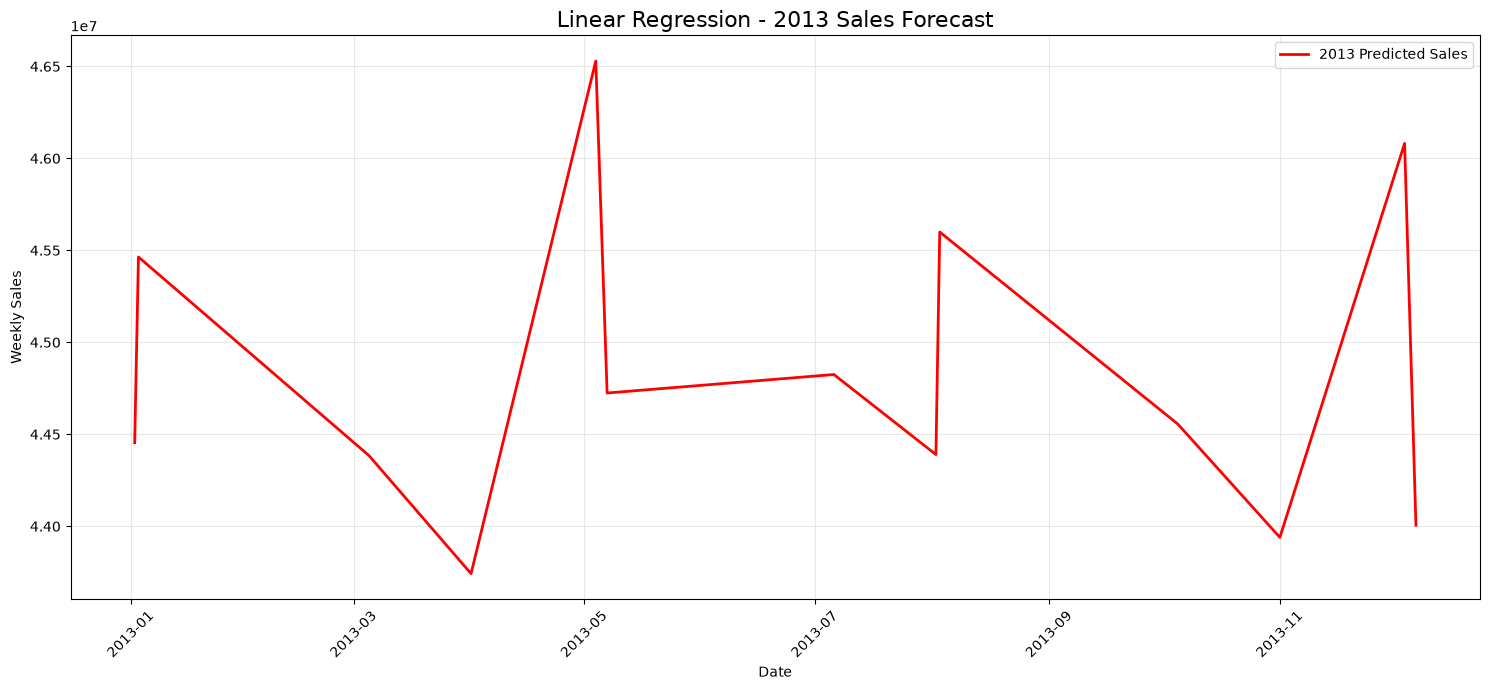

In [ ]:
#linear regression plot predict next years sales 
#saves pipeline into main pipelines folder and the same in the streamlit folder



#feature engineering function
def funcCreateFeatures(df):

    df = df.copy()
    #date features
    df["Year"] = ( df["Date"].dt.year)
    df["Month"] = ( df["Date"].dt.month)
    df["Day"] = (df["Date"].dt.day)
    df["DayOfWeek"] = (df["Date"].dt.dayofweek)
    df["WeekOfYear"] = (df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )
    df["Quarter"] = ( df["Date"].dt.quarter)
    #cyclical features thanks to StackOverflow user chimpsarehungry for the solution
    df["MonthSin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["MonthCos"] = np.cos(2 * np.pi * df["Month"] / 12)
    df["WeekSin"] = np.sin(2 * np.pi * df["WeekOfYear"] / 52)
    df["WeekCos"] = np.cos(2 * np.pi * df["WeekOfYear"] / 52)

    #holiday
    df["IsHoliday"] = (df["IsHoliday"].astype(int))

    return df



#load csv files
dfFeatures = dictDataFrames["Features_DataSet_Visualisation.csv"]
dfSales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
dfStores = dictDataFrames["Stores_DataSet_Visualisation.csv"]
#convert Date to datetime
dfFeatures["Date"] = pd.to_datetime(
    dfFeatures["Date"],
    errors="coerce"
)

dfSales["Date"] = pd.to_datetime(
    dfSales["Date"],
    errors="coerce"
)


#remove invalid dates
dfFeatures = dfFeatures.dropna(
    subset=["Date"]
)

dfSales = dfSales.dropna(
    subset=["Date"]
)

#show date rnage
print("Features Date Range:")
print(f"{dfFeatures['Date'].min()} to {dfFeatures['Date'].max()}")
print()

print("Sales Date Range:")
print(f"{dfSales['Date'].min()} to {dfSales['Date'].max()}")
print()

#merge features and stores
dfFeaturesStores = dfFeatures.merge(
    dfStores,
    on="Store",
    how="left"
)

#show new shape
print(f"Features + Stores Shape: {dfFeaturesStores.shape}")
print()
#create training data

#merge sales with features
dfTrain = dfSales.merge(
    dfFeaturesStores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)

#show shape
print(f"Training Dataset Shape: {dfTrain.shape}")
print()

#create forecast datas
dfForecast = dfFeaturesStores[
    dfFeaturesStores["Date"] >
    dfSales["Date"].max()
].copy()

#we need predictions for every Store/Department!
#get rid of duplicates
dfStoreDepts = dfSales[ ["Store", "Dept"] ].drop_duplicates()

#merge forecast with departments 
dfForecast = dfForecast.merge(
    dfStoreDepts,
    on="Store",
    how="inner"
)

#show shape
print(f"Forecast Dataset: {dfForecast.shape}")
print()

#show date range
print("Forecast Date Range:")
print(f"{dfForecast['Date'].min()} to {dfForecast['Date'].max()}")
print()

#configure DataFrames
dfTrain= funcCreateFeatures(dfTrain)
dfForecast = funcCreateFeatures(dfForecast)

#define markdown columns
lstMarkdown = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]


for column in lstMarkdown:
    if column in dfTrain.columns:
       dfTrain[column] = (
            dfTrain[column]
            .fillna(0)
       )

    if column in dfForecast.columns:
       dfForecast[column] = (
            dfForecast[column]
            .fillna(0)
       )


#define features
lstFeatures = [

    # Store information
    "Store",
    "Dept",
    "Store_Type",
    "Size",

    # Date information
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",

    # Cyclical features
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",

    # Holiday
    "IsHoliday",

    # Walmart economic features
    "Temperature",
    "Unemployment",

    # Markdown
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

#define target
strTarget = "Weekly_Sales"

#check columns
objMissingColumns = [
    column
    for column in lstFeatures
    if column not in dfTrain.columns
]

#missing columns?
if objMissingColumns:
    raise ValueError(
        f"Missing columns: {objMissingColumns}"
    )


#setup X and y for training and forecasting
dfXTrain = dfTrain[lstFeatures]
dfyTrain = dfTrain[strTarget]
dfXForecast = dfForecast[lstFeatures]

#define numeric features
lstNumericFeatures = [
    "Size",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",
    "IsHoliday",
    "Temperature",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

#define categorical features
lstCategoricalFeatures = [
    "Store",
    "Dept",
    "Store_Type"
]

#configure numeric transformer
objNumericTransformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

#configure categorical transformer
objCategoricalTransformer = Pipeline(
    steps=[

        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

#configure column transformer
objPreProcessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),

        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)

#create linear regression model
objModel = LinearRegression()

#configure pipeline
objPipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            objPreProcessor
        ),
        (
            "model",
            objModel
        )
    ]
)


#train model
print("Training Linear Regression...")
objPipeline.fit(dfXTrain, dfyTrain)

print("Training complete")
print()

#save pipeline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_PATH
)

print("Pipeline Saved To:")

print(CNST_STR_LINEAR_PIPELINE_HYPOTHESIS12_PATH)
print()

#start prediction!
print("Generating 2013 Sales Predictions:")
print()

dfForecast["Predicted_Sales"] = (
    objPipeline.predict(
        dfXForecast
    )
)


#select 2013 predictions
dfTest = dfForecast.copy()
dfTest = dfTest[ dfTest["Date"].dt.year == 2013]

#show rows
print(f"2013 Sales Prediction Rows: {len(dfTest)}")
print()

#show date range
print("2013 Sales Prediction Period:")
print(f"{dfTest['Date'].min()} to {dfTest['Date'].max()}")
print()

#aggregate prediction values
dfForecast = (
    dfTest
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)


#get actual sales for 2012 to compare with 2013 predictions
dfActualSales = dfTrain.copy()
dfActualSales = dfActualSales[
    dfActualSales["Year"] == 2012
]

#aggregate actual sales for 2012
dfPrevious = (
    dfActualSales
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

#make sure we don't get a clash of names in the plot!
dfPrevious = dfPrevious.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)


#merge forecast with previous year sales for comparison
dfPlot= dfForecast.merge(
    dfPrevious,
    on="WeekOfYear",
    how="left"
)

#sort by Date
dfPlot = dfPlot.sort_values("Date")

#show OLS summary for predicted sales vs previous year sales
ols_model = smf.ols("Predicted_Sales ~ WeekOfYear + Previous_Year_Sales", 
                    data=dfPlot).fit()
print(ols_model.summary())
print()


#create plot
plt.figure(figsize=(15, 7))

plt.plot(
    dfPlot["Date"],
    dfPlot["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)

plt.title(
    "Linear Regression - 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
#make sure ticks are readable
plt.xticks(rotation=45)
plt.tight_layout()

#save plot to report folder
plt.savefig(
    CNST_STR_LINEAR_PLOT_HYPOTHESIS12_PATH,
    dpi=300,
    bbox_inches="tight"
)

print("Plot Saved!")
print(CNST_STR_LINEAR_PLOT_HYPOTHESIS12_PATH)
print()

plt.show()

# Random Forest Model - Hypothesis 12 - Plot

Sales: 2010-01-10 00:00:00 to 2012-12-10 00:00:00

Features: 2010-01-10 00:00:00 to 2013-12-07 00:00:00

Training Rows: 168156
Forecast Rows: 240754

Training Random Forest...
Training Complete

Pipeline Saved To:
assets/pipelines/randomforest_regression_hypothesis12_pipeline.pkl

Generating Predictions...

Amount of 2013 Rows: 42874

2013 Period:
2013-01-02 00:00:00 to 2013-12-07 00:00:00

                            OLS Regression Results                            
Dep. Variable:        Predicted_Sales   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.9937
Date:                Wed, 26 Aug 2026   Prob (F-statistic):              0.467
Time:                        16:05:51   Log-Likelihood:                -85.261
No. Observations:                   6   AIC:                             176.5
Df Residuals:                       3   BIC:         

/Users/rogerwilliams/Projects/Python/CourseProjects/Project2-SalesAnalysis/.venv/lib/python3.14/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Plot Saved To:
reports/images/forest_regression_hypothesis12_forecast.png



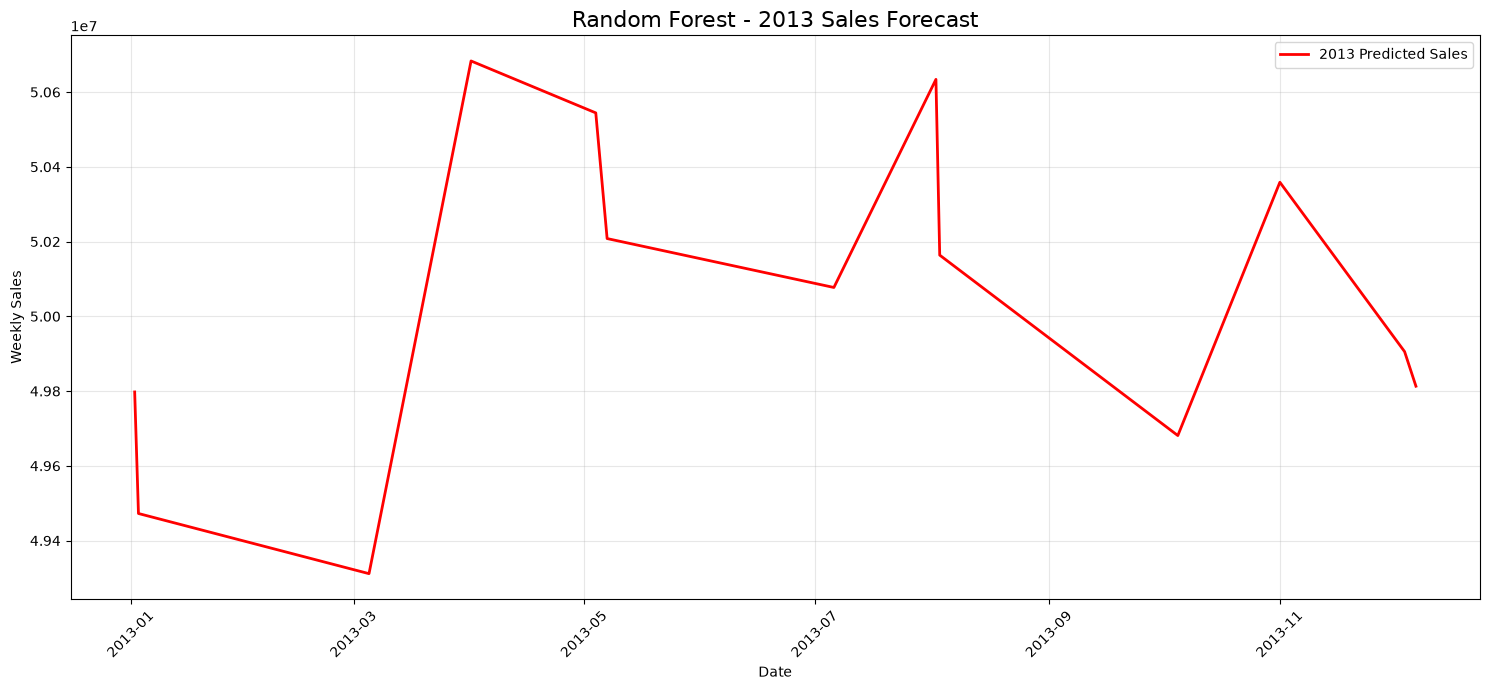

In [ ]:
#random forest predict next years sales
#saves pipeline into main pipelines folder 


def funcCreateFeatures(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = (
        df["Date"].dt.dayofweek
    )

    df["WeekOfYear"] = (
        df["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    df["Quarter"] = (
        df["Date"].dt.quarter
    )

    df["MonthSin"] = np.sin(
        2 * np.pi * df["Month"] / 12
    )

    df["MonthCos"] = np.cos(
        2 * np.pi * df["Month"] / 12
    )

    df["WeekSin"] = np.sin(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["WeekCos"] = np.cos(
        2 * np.pi *
        df["WeekOfYear"] / 52
    )

    df["IsHoliday"] = (
        df["IsHoliday"]
        .astype(int)
    )

    return df


#load csv files
dfFeatures = dictDataFrames["Features_DataSet_Visualisation.csv"]
dfSales = dictDataFrames["Sales_DataSet_Visualisation.csv"]
dfStores = dictDataFrames["Stores_DataSet_Visualisation.csv"]

#convert Date to datetime
dfFeatures["Date"] = pd.to_datetime(
    dfFeatures["Date"],
    errors="coerce"
)

dfSales["Date"] = pd.to_datetime(
    dfSales["Date"],
    errors="coerce"
)

#delete rows with invalid dates
dfFeatures = dfFeatures.dropna(
    subset=["Date"]
)

dfSales = dfSales.dropna(
    subset=["Date"]
)

#show date range
print(f"Sales: {dfSales['Date'].min()} to {dfSales['Date'].max()}")
print()

print(
    f"Features: {dfFeatures['Date'].min()} to {dfFeatures['Date'].max()}"
)
print()

#merge features and stores
dfFeaturesStores = dfFeatures.merge(
    dfStores,
    on="Store",
    how="left"
)

#,erge sales and featuresstores
dfTraining = dfSales.merge(
    dfFeaturesStores,
    on=[
        "Store",
        "Date",
        "IsHoliday"
    ],
    how="left"
)


#create forecast data
dfForecast = dfFeaturesStores.copy()
dfForecast[
    dfForecast["Date"] >
    dfSales["Date"].max()
]

dfStoreDepts = dfSales[
    ["Store", "Dept"]
].drop_duplicates()


dfForecast = dfForecast.merge(
    dfStoreDepts,
    on="Store",
    how="inner"
)

#show rows
print(f"Training Rows: {len(dfTraining)}")
print(f"Forecast Rows: {len(dfForecast)}")
print()

#sprinkle some feature engineering
dfTrain = funcCreateFeatures(dfTrain)
dfForecast = funcCreateFeatures(dfForecast)

#configure markdown columns
lstMarkdown = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

#process
for column in lstMarkdown:
    if column in dfTraining.columns:
        dfTraining[column] = (
            dfTraining[column]
            .fillna(0)
        )

    if column in dfForecast.columns:
        dfForecast[column] = (
            dfForecast[column]
            .fillna(0)
        )


#configure features
lstFeatures = [
    "Store",
    "Dept",
    "Store_Type",
    "Size",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",
    "IsHoliday",
    "Temperature",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

#setup train
dfXtrain = dfTrain[
    lstFeatures
]

dfyTrain = dfTrain[
    "Weekly_Sales"
]

dfXForecast = dfForecast[
    lstFeatures
]


#configure numeric features
lstNumericFeatures = [
    "Size",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Quarter",
    "MonthSin",
    "MonthCos",
    "WeekSin",
    "WeekCos",
    "IsHoliday",
    "Temperature",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

#configure categorical features
lstCategoricalFeatures = [
    "Store",
    "Dept",
    "Store_Type"
]

#configure numeric transformer
objNumericTransformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

#configure categorical transformer
objCategoricalTransformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

#configure column transformer
objPreProcessor = ColumnTransformer(
    transformers=[

        (
            "numeric",
            objNumericTransformer,
            lstNumericFeatures
        ),

        (
            "categorical",
            objCategoricalTransformer,
            lstCategoricalFeatures
        )
    ]
)


#create model
objModel = RandomForestRegressor(
    n_estimators=20,  #50
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

#create pipeline
objPipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            objPreProcessor
        ),

        (
            "model",
            objModel
        )
    ]
)


#train model
print("Training Random Forest...")

objPipeline.fit(
    dfXtrain,
    dfyTrain
)

print("Training Complete")
print()

#save pipeline to main folder
joblib.dump(
    objPipeline,
    CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_PATH
)

print("Pipeline Saved To:")
print(CNST_STR_FOREST_PIPELINE_HYPOTHESIS12_PATH)
print()

#run prediction for 2013 sales
print("Generating Predictions...")
print()
dfForecast["Predicted_Sales"] = (
    objPipeline.predict(
        dfXForecast
    )
)

#get 2013 data
dfPredictedSales = dfForecast.copy()
dfPredictedSales = dfPredictedSales[dfPredictedSales["Date"].dt.year == 2013]

#print data rows count
print(f"Amount of 2013 Rows: {len(dfPredictedSales)}")
print()

print("2013 Period:")
print(f"{dfPredictedSales['Date'].min()} to {dfPredictedSales['Date'].max()}")
print()

#aggreagate sales
dfForecastSales = (
    dfPredictedSales
    .groupby(
        ["Date", "WeekOfYear"]
    )["Predicted_Sales"]
    .sum()
    .reset_index()
)

#get 2012 sales
dfActualSales = dfTrain.copy()
dfActualSales= dfActualSales[dfActualSales["Year"] == 2012]

#get previous years sales
dfPreviousSales = (
    dfActualSales
    .groupby(
        "WeekOfYear"
    )["Weekly_Sales"]
    .sum()
    .reset_index()
)

#make sure we don't get a clash of names in the plot!
dfPreviousSales = dfPreviousSales.rename(
    columns={
        "Weekly_Sales":
        "Previous_Year_Sales"
    }
)

#merge forecastsales with previoussales
dfPlot = dfForecastSales.merge(
    dfPreviousSales,
    on="WeekOfYear",
    how="left"
)

#sort by Date
dfPlot = dfPlot.sort_values("Date")

#show OLS summary for predicted sales vs previous year sales
ols_model = smf.ols("Predicted_Sales ~ WeekOfYear + Previous_Year_Sales", 
                    data=dfPlot).fit()
print(ols_model.summary())
print()

#create plot
plt.figure(figsize=(15, 7))

plt.plot(
    dfPlot["Date"],
    dfPlot["Predicted_Sales"],
    color="red",
    linewidth=2,
    label="2013 Predicted Sales"
)

plt.title(
    "Random Forest - 2013 Sales Forecast",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.grid(alpha=0.3)
#make sure ticks are readable
plt.xticks(rotation=45)
plt.tight_layout()

#save image to report folder
plt.savefig(
    CNST_STR_FOREST_PLOT_HYPOTHESIS12_PATH,
    dpi=300,
    bbox_inches="tight"
)


print("Plot Saved To:")
print(CNST_STR_FOREST_PLOT_HYPOTHESIS12_PATH)
print()

plt.show()

# Observations - Regression Types Hypothesis 12 - Plot

While the models are close in performance, the Random Forest model demonstrates a slight edge in predictive accuracy for sales forecasting  
with an R squared

# Conclusions - Hypothesis 12

While the models are close in performance, the Random Forest model demonstrates a slight edge in predictive accuracy for sales forecasting  
The plots looks closer to the mean than the linear regression model, and I prefer the closeness of the random forest's R Squared value

Running the OLS summary for Weekly_Sales for both linear regression and random forest was interesting as even though technically the results 
are meaningless they were very close to each other and not so close to zero that Hypothesis Zero would be true!

Also could not use a confusion matrix as using continuous values, pity heatmaps look cool...